# Unit 5 code companion: Regression as Reasoning

What least squares actually minimizes, why a slope has a standard error, how a dummy variable turns a t-test into a regression, and how a lurking variable rewrites a coefficient in front of you.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
print(cars.shape); cars.head()

(392, 9)


,mpg,cylinder,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,American,chevrolet
1,15.0,8,350.0,165,3693,11.5,70,American,buick
2,18.0,8,318.0,150,3436,11.0,70,American,plymouth
3,16.0,8,304.0,150,3433,12.0,70,American,amc
4,17.0,8,302.0,140,3449,10.5,70,American,ford


## 1. A first fit, read out loud



In [2]:
X = sm.add_constant(cars[["weight"]])
fit = sm.OLS(cars["mpg"], X).fit()
b0, b1 = fit.params["const"], fit.params["weight"]
print(fit.summary().tables[1])
print(f"\nSlope = {b1:.5f} mpg per pound.")
print(f"Per 1000 lbs: {1000*b1:.2f} mpg.  <-- always rescale to units a human can feel")
print(f"Weight range in the data: {cars.weight.min():.0f} to {cars.weight.max():.0f} lbs")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.2165      0.799     57.867      0.000      44.646      47.787
weight        -0.0076      0.000    -29.645      0.000      -0.008      -0.007

Slope = -0.00765 mpg per pound.
Per 1000 lbs: -7.65 mpg.  <-- always rescale to units a human can feel
Weight range in the data: 1613 to 5140 lbs


The raw slope, $-0.0076$, looks like nothing. Per 1,000 pounds it is $-7.6$ mpg, which is enormous. Same number, same model: the units decide whether anyone understands you.

## 2. What least squares actually minimizes

Try a grid of candidate slopes and watch the sum of squared residuals bottom out at exactly the fitted value.

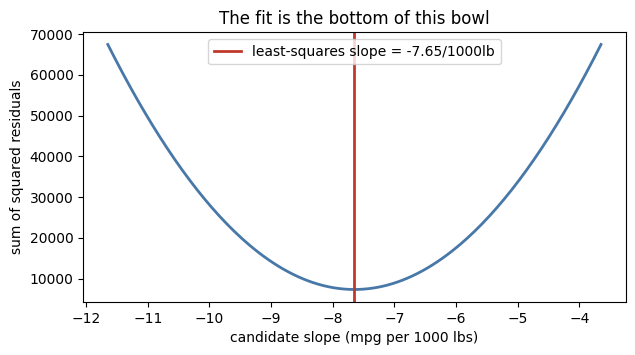

In [3]:
slopes = np.linspace(b1 - 0.004, b1 + 0.004, 200)
sse = [((cars.mpg - (b0 + s*cars.weight))**2).sum() for s in slopes]
plt.plot(slopes*1000, sse, color="#4878a8", lw=2)
plt.axvline(b1*1000, color="#c0392b", lw=2, label=f"least-squares slope = {b1*1000:.2f}/1000lb")
plt.xlabel("candidate slope (mpg per 1000 lbs)"); plt.ylabel("sum of squared residuals")
plt.legend(); plt.title("The fit is the bottom of this bowl"); plt.show()

## 3. A slope is an estimate, so it wobbles

Resample the data and refit. The spread of the slopes IS the standard error.

In [4]:
boot_slopes = []
for _ in range(2000):
    samp = cars.sample(len(cars), replace=True)
    boot_slopes.append(np.polyfit(samp.weight, samp.mpg, 1)[0])
boot_slopes = np.array(boot_slopes)

print(f"bootstrap SE of the slope : {boot_slopes.std()*1000:.3f} (per 1000 lbs)")
print(f"statsmodels SE            : {fit.bse['weight']*1000:.3f} (per 1000 lbs)")
print(f"t = slope/SE              : {fit.tvalues['weight']:.1f}   <-- the Unit 1 template again")

bootstrap SE of the slope : 0.235 (per 1000 lbs)
statsmodels SE            : 0.258 (per 1000 lbs)
t = slope/SE              : -29.6   <-- the Unit 1 template again


## 4. A dummy variable IS a two-group comparison

Regression on a 0/1 predictor reproduces the two-sample t-test exactly.

In [5]:
cars["is_american"] = (cars["origin"] == "American").astype(int)
d = sm.OLS(cars["mpg"], sm.add_constant(cars[["is_american"]])).fit()

amer = cars.loc[cars.is_american == 1, "mpg"]
other = cars.loc[cars.is_american == 0, "mpg"]

print(f"regression intercept (non-American mean) : {d.params['const']:.3f}")
print(f"actual non-American mean                 : {other.mean():.3f}")
print(f"regression dummy coefficient (difference): {d.params['is_american']:.3f}")
print(f"actual difference in means               : {amer.mean() - other.mean():.3f}")
print(f"\nregression t = {d.tvalues['is_american']:.3f}")
print(f"pooled two-sample t = {stats.ttest_ind(amer, other, equal_var=True).statistic:.3f}")

regression intercept (non-American mean) : 29.133
actual non-American mean                 : 29.133
regression dummy coefficient (difference): -9.100
actual difference in means               : -9.100

regression t = -13.529
pooled two-sample t = -13.529


They are the same procedure. Everything you learned about two-group tests in Unit 1 transfers directly to regression coefficients. Only the packaging changed.

## 5. Omitted-variable bias, where you know the truth

Simulate a world in which x has NO effect on y, but both are driven by z.

In [6]:
n = 3000
z = rng.normal(0, 1, n)                    # the lurking variable
x = 0.8*z + rng.normal(0, 0.6, n)          # x is driven by z
y = 2.0*z + rng.normal(0, 1.0, n)          # y is driven by z, NOT by x

naive = sm.OLS(y, sm.add_constant(x)).fit()
adjusted = sm.OLS(y, sm.add_constant(np.column_stack([x, z]))).fit()

print(f"TRUE effect of x on y            : 0.000")
print(f"naive slope on x                 : {naive.params[1]:.3f}  (t = {naive.tvalues[1]:.1f})")
print(f"slope on x, controlling for z    : {adjusted.params[1]:.3f}  (t = {adjusted.tvalues[1]:.1f})")

TRUE effect of x on y            : 0.000
naive slope on x                 : 1.578  (t = 55.7)
slope on x, controlling for z    : -0.035  (t = -1.1)


The naive regression reports a large, overwhelmingly significant effect of something that does nothing. No amount of data fixes it: with more rows the t-statistic just grows. Only including z fixes it, and in real work you have to *know* to look for z.

## 6. The same thing, in real data

Do slower-accelerating cars really get better mileage?

In [7]:
raw = sm.OLS(cars["mpg"], sm.add_constant(cars[["acceleration"]])).fit()
adj = sm.OLS(cars["mpg"], sm.add_constant(cars[["acceleration", "weight"]])).fit()

print(f"raw slope on acceleration            : {raw.params['acceleration']:+.3f} mpg per second")
print(f"controlling for weight               : {adj.params['acceleration']:+.3f} mpg per second")
print(f"the raw association shrank by        : "
      f"{100*(1 - adj.params['acceleration']/raw.params['acceleration']):.0f}%")
print(f"\ncorr(acceleration, weight) = {cars.acceleration.corr(cars.weight):+.2f}")

raw slope on acceleration            : +1.198 mpg per second
controlling for weight               : +0.262 mpg per second
the raw association shrank by        : 78%

corr(acceleration, weight) = -0.42


Heavy cars are both slow to accelerate and thirsty. Most of the raw relationship was weight under another name. We did **not** prove that acceleration has no effect. We showed that the raw number was mostly something else.

## 7. Significant does not mean useful



In [8]:
m = sm.OLS(cars["mpg"], sm.add_constant(cars[["acceleration"]])).fit()
print(f"p-value on acceleration : {m.pvalues['acceleration']:.2e}")
print(f"R-squared               : {m.rsquared:.3f}")
print(f"residual SD             : {np.sqrt(m.scale):.2f} mpg")
print("\nOverwhelmingly significant, and it explains under a fifth of the variation.")
print("Those two facts answer different questions and neither one is 'is the model good'.")

p-value on acceleration : 1.78e-18
R-squared               : 0.179
residual SD             : 7.08 mpg

Overwhelmingly significant, and it explains under a fifth of the variation.
Those two facts answer different questions and neither one is 'is the model good'.
